## Entrenamiento de modelo de ML 

La idea es poder generar varios entrenamientos de 2 maneras de supervision (supervizado o no supervisado).  Veremos como se transforman y actua. 

## Entrenamiento no supervizado (IsolationForest)

se realiza un entrenamiento basico. 


In [4]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np

def cargar(bit):
    """Lee el CSV generado en el notebook 05 para un bit dado."""
    df = pd.read_csv(f'../data/processed/cca_o3_bit{bit:02d}_tasa05.csv',
                     parse_dates=['timestamp'])
    return df[df.received_value.notna()].copy()


def features(df, con_hora=True):
    """Construye la matriz de entrada del modelo.

    Solo received_value y hora. NUNCA original_value, bit, daño ni
    atacado: esas son verdad de campo, no informacion disponible en
    produccion.
    """
    X = pd.DataFrame(index=df.index)
    v = df.received_value
    X['valor_log'] = np.sign(v) * np.log1p(np.abs(v))
    if con_hora:
        X['hora_sin'] = np.sin(2*np.pi*df.hora/24)
        X['hora_cos'] = np.cos(2*np.pi*df.hora/24)
    return X

In [5]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score

res = []
for bit in range(13):
    df = cargar(bit)
    X = features(df, con_hora=True)
    y = df.atacado.values          # SOLO para evaluar, nunca para entrenar

    modelo = IsolationForest(contamination=0.05, random_state=42)
    pred = (modelo.fit_predict(X) == -1).astype(int)

    res.append({
        'bit': bit,
        'delta_ppb': 2**bit,
        'recall_%': round(recall_score(y, pred)*100, 1),
        'precision_%': round(precision_score(y, pred, zero_division=0)*100, 1),
        'fp': int(((pred==1) & (y==0)).sum()),
    })

pd.DataFrame(res)

,bit,delta_ppb,recall_%,precision_%,fp
0,0,1,5.1,5.0,323
1,1,2,11.4,11.2,302
2,2,4,6.9,6.8,316
3,3,8,7.8,7.8,308
4,4,16,12.3,12.1,297
5,5,32,18.6,18.2,278
6,6,64,43.7,45.1,178
7,7,128,79.9,78.5,73
8,8,256,89.8,90.4,32
9,9,512,100.0,98.2,6


## Conclusiones del entrenamiento sin supervicion. 

Frontera de detección: bit 7. A partir de desplazamientos de 128 ppb el detector por magnitud alcanza 79.9% de recall, y desde el bit 9 (512 ppb) la detección es total. Esos ataques producen además valores fuera del rango físicamente observado (máximo histórico de CCA: 149 ppb), por lo que se autodelatan.

Región explotable: bits 5 y 6. El bit 6 (64 ppb) maximiza el daño no detectado: causa cambio de banda en el 100% de los ataques y solo el 43.7% se detecta. El bit 5 (32 ppb) es la segunda mejor opción, con 29% de daño frente a 18.6% de detección.

Bits 0 a 4 no aportan al adversario. Su detección está en el nivel de azar (5–12%, contra una línea base de 5% impuesta por contamination=0.05), pero su daño también es bajo. Son invisibles e inofensivos.

El adversario no maximiza magnitud. Existe un óptimo interior: por debajo el ataque es invisible pero inútil; por encima es efectivo pero evidente.

## Entrenamiento supervizado. 

En esta celda se usaran entrenamientos rapidos con lazy

In [6]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

df = cargar(5)                      # bit 5: la zona explotable
X, y = features(df), df.atacado
# Split cronologico. NUNCA train_test_split: barajaria los datos
# y produciria fuga de informacion en una serie temporal.
Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#n = int(len(X) * 0.8)
#Xtr, Xte = X[:n], X[n:]
#ytr, yte = y[:n], y[n:]

print(f"Entrenamiento: {len(Xtr)}  ({ytr.sum()} atacados)")
print(f"Prueba:        {len(Xte)}  ({yte.sum()} atacados)")

clf = LazyClassifier(verbose=0, ignore_warnings=True)
modelos, _ = clf.fit(Xtr, Xte, ytr, yte)
modelos.head(10)

Entrenamiento: 5430  (267 atacados)
Prueba:        1358  (67 atacados)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
Perceptron,0.734904,0.726141,0.759934,0.809617,0.938110,0.734904,0.012930
NearestCentroid,0.553756,0.666243,0.653028,0.670532,0.936050,0.553756,0.016909
KNeighborsClassifier,0.959499,0.639080,0.800739,0.950888,0.952459,0.959499,0.016864
BaggingClassifier,0.944035,0.638022,0.776108,0.939887,0.936667,0.944035,0.044482
DecisionTreeClassifier,0.953608,0.635982,0.679775,0.946322,0.943768,0.953608,0.016279
LabelPropagation,0.962445,0.626478,0.886956,0.951970,0.961787,0.962445,0.317959
ExtraTreesClassifier,0.952135,0.621056,0.711481,0.943995,0.941026,0.952135,0.190300
ExtraTreeClassifier,0.949926,0.619894,0.670873,0.942378,0.938698,0.949926,0.012883
RandomForestClassifier,0.949190,0.619507,0.834624,0.941845,0.938005,0.949190,0.211417


## Primer corrida realizada

In [7]:
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, fbeta_score

MODELOS = {
    'DecisionTree': lambda: DecisionTreeClassifier(random_state=42),
    'RandomForest': lambda: RandomForestClassifier(random_state=42),
    'KNeighbors':   lambda: KNeighborsClassifier(),
}

res = []
for bit in range(13):
    df = cargar(bit)
    X, y = features(df), df.atacado.values
    n = int(len(X) * 0.8)
    Xtr, Xte, ytr, yte = X[:n], X[n:], y[:n], y[n:]

    for nombre, factory in MODELOS.items():
        m = factory()
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        # pos_label=1: metricas sobre la clase ATACADO unicamente
        res.append({
            'bit': bit,
            'delta_ppb': 2**bit,
            'modelo': nombre,
            'ataques_test': int(yte.sum()),
            'detectados': int(((pred == 1) & (yte == 1)).sum()),
            'falsos_pos': int(((pred == 1) & (yte == 0)).sum()),
            'recall_%': round(recall_score(yte, pred, pos_label=1,
                                           zero_division=0) * 100, 1),
            'precision_%': round(precision_score(yte, pred, pos_label=1,
                                                 zero_division=0) * 100, 1),
            'f2_%': round(fbeta_score(yte, pred, beta=2, pos_label=1,
                                      zero_division=0) * 100, 1),
        })

sup = pd.DataFrame(res)

os.makedirs('../results', exist_ok=True)
sup.to_csv('../results/deteccion_supervisada.csv', index=False)

# Vista compacta: recall por modelo
recall_tabla = sup.pivot_table(index=['bit', 'delta_ppb'],
                               columns='modelo', values='recall_%').reset_index()
recall_tabla.columns.name = None
recall_tabla.columns = ['bit', 'Δ ppb', 'Recall DecisionTree (%)',
                        'Recall KNeighbors (%)', 'Recall RandomForest (%)']
recall_tabla


,bit,Δ ppb,Recall DecisionTree (%),Recall KNeighbors (%),Recall RandomForest (%)
0,0,1,2.9,0.0,2.9
1,1,2,5.7,4.3,4.3
2,2,4,4.3,1.4,4.3
3,3,8,4.3,0.0,4.3
4,4,16,8.6,1.4,8.6
5,5,32,41.4,35.7,41.4
6,6,64,72.9,71.4,72.9
7,7,128,97.1,98.6,98.6
8,8,256,100.0,100.0,100.0
9,9,512,100.0,100.0,100.0


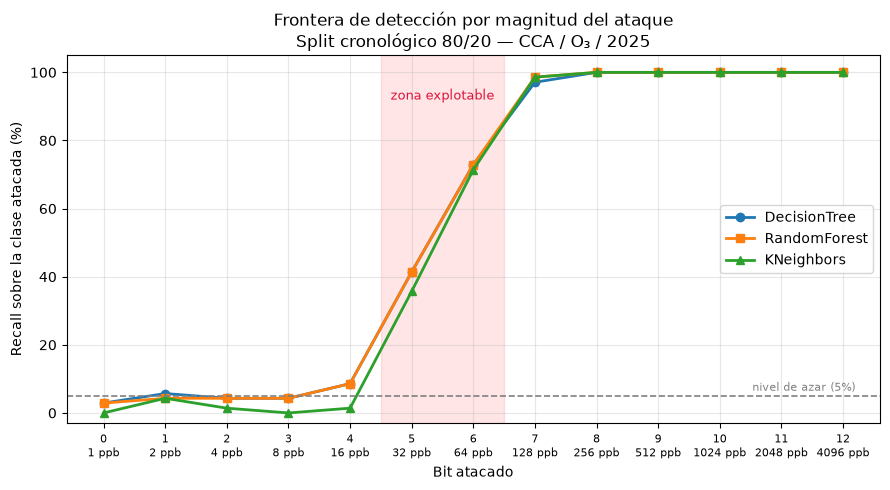

In [8]:
import matplotlib.pyplot as plt

t = recall_tabla
bits = t['bit'].values

fig, ax = plt.subplots(figsize=(9, 5))

for col, marca in [('Recall DecisionTree (%)', 'o'),
                   ('Recall RandomForest (%)', 's'),
                   ('Recall KNeighbors (%)', '^')]:
    ax.plot(bits, t[col], marca + '-', lw=2, markersize=6,
            label=col.replace('Recall ', '').replace(' (%)', ''))

# Linea base: contamination = 5% marca al azar
ax.axhline(5, ls='--', c='gray', lw=1.2)
ax.text(12.2, 6.5, 'nivel de azar (5%)', fontsize=8, c='gray', ha='right')

# Zona explotable
ax.axvspan(4.5, 6.5, alpha=0.10, color='red')
ax.text(5.5, 92, 'zona explotable', ha='center', fontsize=9, color='crimson')

ax.set_xlabel('Bit atacado')
ax.set_ylabel('Recall sobre la clase atacada (%)')
ax.set_title('Frontera de detección por magnitud del ataque\nSplit cronológico 80/20 — CCA / O₃ / 2025')
ax.set_xticks(bits)
ax.set_xticklabels([f'{b}\n{d} ppb' for b, d in zip(bits, t['Δ ppb'])], fontsize=8)
ax.set_ylim(-3, 105)
ax.legend(loc='center right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/img/frontera_deteccion.png', dpi=150)
plt.show()

## Revision de los datos con estratificado definitivo proporcionado por el Doc Jaime y claude

Tenemos que relizar estratificado para comprobar que nuestro entrenamiento contiene tambien datos flipeados. Claude afirma que este no es el caso pues el flip tiene los ataques en multiples lados no solo al final por lo que, matematicamente hablando no puede quedarse por si solo. 

pero por ordenes del Doc y cursiosidad propia con apoyo de Claude, revisare como se comporta el entrenamiento con el estratificado que se estara realizando.

In [9]:
df = cargar(5)
X, y = features(df), df.atacado.values

n = int(len(X) * 0.8)
ytr, yte = y[:n], y[n:]

print(f"Total:  {len(y)} filas, {y.sum()} ataques ({y.mean()*100:.2f}%)")
print(f"Train:  {len(ytr)} filas, {ytr.sum()} ataques ({ytr.mean()*100:.2f}%)")
print(f"Test:   {len(yte)} filas, {yte.sum()} ataques ({yte.mean()*100:.2f}%)")

Total:  6788 filas, 334 ataques (4.92%)
Train:  5430 filas, 264 ataques (4.86%)
Test:   1358 filas, 70 ataques (5.15%)


## Notas y conclusiones: estratificación (recomendación del Dr Jaime)

El asesor observó que el modelo podría estar entrenándose casi
exclusivamente con datos legítimos, sin ver suficientes ejemplos de
ataque, y recomendó estratificar el split para garantizar la misma
proporción de ataques en ambos conjuntos.

### Por qué la premisa no aplica

El flipeo no se concentra al final de la serie: se aplica con tasa del
5% **distribuido a lo largo de todo el año**. Por construcción, el
split cronológico ya produce conjuntos equilibrados.

| Conjunto | Filas | Ataques | Proporción |
|---|---|---|---|
| Entrenamiento | 5,430 | 264 | 4.86% |
| Prueba | 1,358 | 70 | 5.15% |

Diferencia: **0.29 puntos porcentuales**. El modelo dispuso de 264
ejemplos de ataque durante el entrenamiento.

La estratificación no es necesaria en este caso.

### Implicación

Descartada la falta de ejemplos, la baja detección en bits bajos
(recall de 0% a 8.6% en bits 0-4) no se explica por entrenamiento
insuficiente. La causa es que un desplazamiento de 8 o 16 ppb produce
un valor indistinguible de una lectura legítima cuando se evalúa
aisladamente. **Es un límite del problema, no del entrenamiento.**

### Resultado inesperado del estratificado

| Modelo | Cronológico | Estratificado | Δ |
|---|---|---|---|
| DecisionTree | 0.698 | 0.636 | −6.2 pts |
| RandomForest | 0.697 | 0.620 | −7.7 pts |
| ExtraTrees | 0.692 | 0.621 | −7.1 pts |

*Balanced accuracy, bit 5.*

Se esperaba que el estratificado, al barajar, produjera fuga temporal y
resultados inflados. Ocurre lo contrario: cae entre 6 y 8 puntos, de
forma sistemática en los modelos de árbol.

Esta discrepancia queda pendiente de explicación (ver hipótesis
estacional en la siguiente celda).

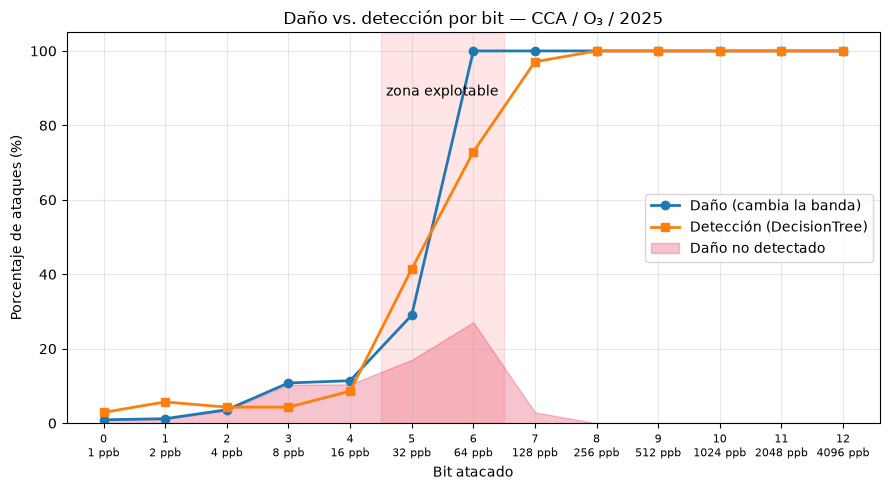

In [10]:
import matplotlib.pyplot as plt

bits = list(range(13))
delta = [2**b for b in bits]

daño       = [0.9, 1.2, 3.6, 10.8, 11.4, 29.0, 100, 100, 100, 100, 100, 100, 100]
deteccion  = [2.9, 5.7, 4.3, 4.3, 8.6, 41.4, 72.9, 97.1, 100, 100, 100, 100, 100]
no_detect  = [d * (1 - t/100) for d, t in zip(daño, deteccion)]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(bits, daño, 'o-', label='Daño (cambia la banda)', lw=2)
ax.plot(bits, deteccion, 's-', label='Detección (DecisionTree)', lw=2)
ax.fill_between(bits, no_detect, alpha=0.25, color='crimson',
                label='Daño no detectado')

ax.axvspan(4.5, 6.5, alpha=0.10, color='red')
ax.annotate('zona explotable', xy=(5.5, 88), ha='center', fontsize=10)

ax.set_xlabel('Bit atacado')
ax.set_ylabel('Porcentaje de ataques (%)')
ax.set_title('Daño vs. detección por bit — CCA / O₃ / 2025')
ax.set_xticks(bits)
ax.set_xticklabels([f'{b}\n{d} ppb' for b, d in zip(bits, delta)], fontsize=8)
ax.set_ylim(0, 105)
ax.legend(loc='center right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/img/daño_vs_deteccion.png', dpi=150)
plt.show()

### Interpretación

El área sombreada representa los ataques que **causan daño y no son
detectados**: el producto de la tasa de daño por la fracción no
detectada.

Su máximo está en el **bit 6** (64 ppb): el 100% de los ataques cambia
la banda reportada y el 72.9% se detecta, dejando un 27.1% de daño
efectivo sin detección.

A la izquierda del bit 5 la detección es baja, pero el daño también:
los ataques son invisibles e inofensivos. A la derecha del bit 7 ambas
curvas convergen en 100% y el área desaparece: los ataques garantizan
daño pero se detectan siempre, y además producen valores fuera del
rango físicamente observado (máximo histórico de CCA en 2025: 149 ppb).

**El adversario no maximiza magnitud.** Existe un óptimo interior.